# Quantum Espresso Workflow 

This notebook builds the Quantum Espresso energy-volume-curve workflow with [`pyironflow`](https://github.com/pyiron/pyironflow). 

## Reload workflow in pyironflow

In [1]:
workflow_json_filename = "workflow.json"

In [2]:
from python_workflow_definition.pyiron_workflow import load_workflow_json

In [3]:
from pyironflow import PyironFlow

In [4]:
wf = load_workflow_json(file_name=workflow_json_filename)
PyironFlow([wf]).gui

![screenshot](screenshot.png)

Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG


{'plot_energy_volume_curve__plot_energy_volume_curve': None}

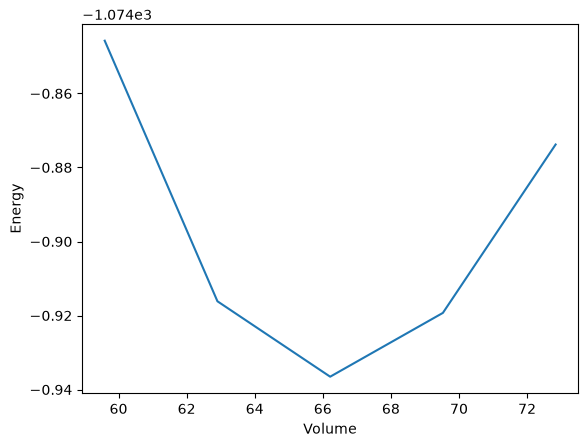

In [5]:
wf.run()

## Define workflow with pyiron_workflow

Plain functions are converted to graph nodes with `to_function_node`, assembled into a `Workflow` via attribute access, and exported as a PWD `workflow.json`.

In [6]:
from inspect import isfunction
import numpy as np
from pyiron_workflow import Workflow, to_function_node, as_function_node
from pyiron_workflow.api import inputs_to_dict
from python_workflow_definition.pyiron_workflow import write_workflow_json

In [7]:
from workflow import (
    calculate_qe as _calculate_qe, 
    generate_structures as _generate_structures, 
    get_bulk_structure as _get_bulk_structure, 
    plot_energy_volume_curve as _plot_energy_volume_curve,
)

`pyiron_workflow` has no built-in equivalent of the `get_list` helper the other engines use to collect several outputs into a list, so `get_values_from_dict` is defined here as a custom node with `as_function_node` to turn a dict of energies/volumes into a plain list for the final plot.

In [8]:
@as_function_node("output_dict")
def get_values_from_dict(input_dict):
    return list(input_dict.values())

In [9]:
calculate_qe = to_function_node("calculate_qe", _calculate_qe, "calculate_qe")
generate_structures = to_function_node("generate_structures", _generate_structures, "generate_structures")
get_bulk_structure = to_function_node("get_bulk_structure", _get_bulk_structure, "get_bulk_structure")
plot_energy_volume_curve = to_function_node("plot_energy_volume_curve", _plot_energy_volume_curve, "plot_energy_volume_curve", validate_output_labels=False)

`to_function_node` wraps each plain Python function into a `pyiron_workflow` node type. `plot_energy_volume_curve` passes `validate_output_labels=False` since it has no return value, so its output cannot be matched to an explicit output label.

In [10]:
wf = Workflow("my_workflow")

In [11]:
wf.pseudopotentials = {"Al": "Al.pbe-n-kjpaw_psl.1.0.0.UPF"}

Nodes are added to the `Workflow` by assigning their result to an attribute of `wf` (e.g. `wf.structure = get_bulk_structure(...)`), which both registers the node and gives it a name in the graph. Since `calculate_qe` expects a single `input_dict` argument, `inputs_to_dict` is used to bundle the structure, pseudopotentials, k-points, calculation type and smearing into one dict-valued node before the first (`vc-relax`) QE calculation.

In [12]:
wf.element = "Al"
wf.a = 4.04
wf.cubic = True
wf.structure = get_bulk_structure(
    element=wf.element,
    a=wf.a,
    cubic=wf.cubic,
)

In [13]:
wf.working_directory_0 = "mini"
input_dict = {
    "structure": wf.structure, 
    "pseudopotentials": wf.pseudopotentials, 
    "kpts": (3, 3, 3), 
    "calculation": "vc-relax", 
    "smearing": 0.02,
}
wf.input_dict_0 = inputs_to_dict(
    input_specification=list(input_dict.keys()),
    **input_dict
)

In [14]:
wf.calc_mini = calculate_qe(
    working_directory=wf.working_directory_0,
    input_dict=wf.input_dict_0,
)

`generate_structures` fans out the relaxed structure into `number_of_strains` (5) strained structures (`wf.structure_lst["s_0"]` ... `["s_4"]`). The loop below builds one `input_dict` and one independent `scf` `calculate_qe` node per strained structure, so five QE calculations run to sample the energy-volume curve.

In [15]:
number_of_strains = 5
wf.strain_lst = np.linspace(0.9, 1.1, number_of_strains)
wf.structure_lst = generate_structures(  # the generate_structures() function is not available in the workflow graph
    structure=wf.calc_mini["structure"],
    strain_lst=wf.strain_lst,
)

In [16]:
job_strain_lst = []
for i in range(number_of_strains):
    setattr(wf, "input_dict_" + str(i+1), inputs_to_dict(
        input_specification=["structure", "pseudopotentials", "kpts", "calculation", "smearing"],
        structure=wf.structure_lst["s_" + str(i)],
        pseudopotentials=wf.pseudopotentials,
        kpts=(3, 3, 3),
        calculation="scf",
        smearing=0.02,
    ))
    setattr(wf, "calc_strain_" + str(i), calculate_qe(
        working_directory="strain_" + str(i),
        input_dict=getattr(wf, "input_dict_" + str(i+1)),
    ))
    job_strain_lst.append(getattr(wf, "calc_strain_" + str(i)))

The `energy` and `volume` outputs of the five strained calculations are bundled with `inputs_to_dict` and then flattened into two plain lists with the `get_values_from_dict` node defined above, ready to be passed to `plot_energy_volume_curve`.

In [17]:
volume_dict = {"s_" + str(i): j["volume"] for i, j in enumerate(job_strain_lst)}
wf.volume_dict = inputs_to_dict(
    input_specification=list(volume_dict.keys()),
    **volume_dict
)
energy_dict = {"s_" + str(i): j["energy"] for i, j in enumerate(job_strain_lst)}
wf.energy_dict = inputs_to_dict(
    input_specification=list(energy_dict.keys()),
    **energy_dict,
)
wf.volume_lst = get_values_from_dict(
    input_dict=wf.volume_dict
)
wf.energy_lst = get_values_from_dict(
    input_dict=wf.energy_dict
)

In [18]:
wf.plot = plot_energy_volume_curve(volume_lst=wf.volume_lst, energy_lst=wf.energy_lst)

`.draw()` renders the assembled node graph, and `write_workflow_json` exports it - using `wf.graph_as_dict` - to the PWD `workflow.json` format so it can be loaded by another engine.

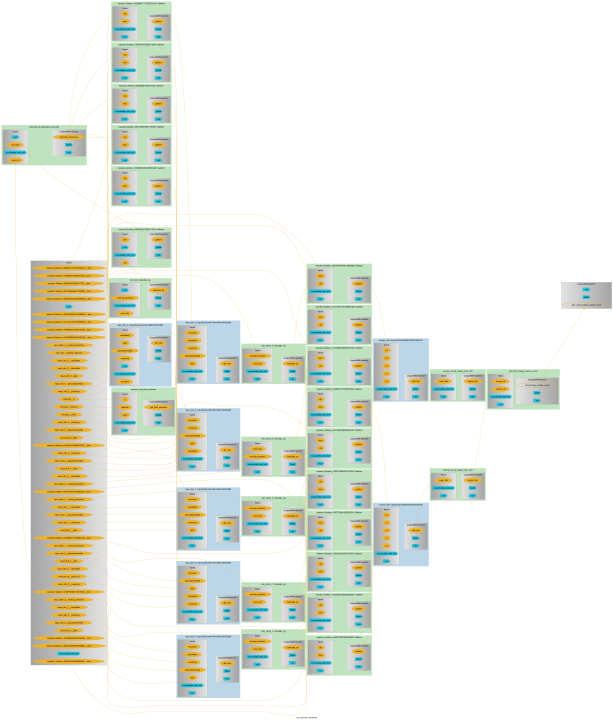

In [19]:
wf.draw(size=(10,10))

In [20]:
write_workflow_json(graph_as_dict=wf.graph_as_dict, file_name=workflow_json_filename)

In [21]:
!cat {workflow_json_filename}

{
  "version": "0.1.0",
  "nodes": [
    {
      "id": 0,
      "type": "function",
      "value": "workflow.get_bulk_structure"
    },
    {
      "id": 1,
      "type": "function",
      "value": "python_workflow_definition.shared.get_dict"
    },
    {
      "id": 2,
      "type": "function",
      "value": "workflow.calculate_qe"
    },
    {
      "id": 3,
      "type": "function",
      "value": "workflow.generate_structures"
    },
    {
      "id": 4,
      "type": "function",
      "value": "python_workflow_definition.shared.get_dict"
    },
    {
      "id": 5,
      "type": "function",
      "value": "workflow.calculate_qe"
    },
    {
      "id": 6,
      "type": "function",
      "value": "python_workflow_definition.shared.get_dict"
    },
    {
      "id": 7,
      "type": "function",
      "value": "workflow.calculate_qe"
    },
    {
      "id": 8,
      "type": "function",
      "value": "python_workflow_definition.shared.get_dict"
    },
    {
      "id": 9,
      "t